# AuditLens
## Audit Analytics & Anomaly Detection Pipeline

End-to-end pipeline: generate synthetic journal entries with planted
anomalies, run rule-based audit tests, layer on ML anomaly detection,
score risk, validate against ground truth, and produce the audit findings
report and dashboard export.




## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

BASE_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(BASE_DIR, 'data')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

### Generate/Load the synthetic dataset

`generate_data.py` builds a synthetic general-ledger-style dataset: ~8,000
normal transactions plus ~140 injected anomalies across six categories
(duplicates, round numbers, off-hours postings, vendor concentration,
statistical outliers, month-end spikes). Ground truth labels are stored
separately for validation


In [2]:
GENERATE_FRESH_DATA = False # set True to force regeneration of the synthetic dataset

csv_path = os.path.join(DATA_DIR, 'journal_entries.csv')

if GENERATE_FRESH_DATA or not os.path.exists(csv_path):
    print('Generating synthetic journal entries...')
    import generate_data  # runs on import
else:
    print('journal_entries.csv already exists - reusing it for reproducible results.')
    print('Set GENERATE_FRESH_DATA = True above to regenerate.')

Generating synthetic journal entries...
Generated 8140 total transactions
  Normal:   8000
  Injected anomalies: 140
Saved to c:\Users\sonak\OneDrive\Desktop\sushi\pen drive\sonakshi_projects\Data_Analytics\AuditLens\auditlens\data/journal_entries.csv and ground_truth.csv


## 2. Load, Clean, Profile & Load into SQLite

In [3]:
from ingestion import load_raw_csv, clean, load_to_sqlite, profile

raw = load_raw_csv()
df = clean(raw)
df.head()

Cleaning: 8140 -> 8140 rows (0 dropped for nulls/exact dupes)


,transaction_id,date,time,department,account,vendor,amount,entry_type,posted_by,description,day_of_week,is_weekend,hour,month,day
0,JE105798,2025-09-10,06:56:42,Sales,Rent,Williams and Sons,105467.64,Debit,Cynthia Allen,Embrace proactive communities,Wednesday,False,6,9,10
1,JE104304,2025-10-01,08:43:57,Operations,Rent,"Rodriguez, Figueroa and Sanchez",170580.22,Credit,Jacqueline Lam,Cultivate granular technologies,Wednesday,False,8,10,1
2,JE101129,2025-12-22,10:37:36,Marketing,Payroll,"Reid, Ferguson and Sanchez",43579.78,Credit,Jacqueline Lam,Repurpose end-to-end action-items,Monday,False,10,12,22
3,JE105363,2025-08-15,08:53:50,Marketing,Inventory,"Hoffman, Baker and Richards",36099.89,Debit,Jack Galloway,Morph value-added functionalities,Friday,False,8,8,15
4,JE103785,2025-12-01,10:34:46,IT,Inventory,Doyle Ltd,44147.35,Debit,Julian Chapman,Matrix sticky niches,Monday,False,10,12,1


In [4]:
profile(df)


--- DATA PROFILE ---
Rows: 8140   Columns: 15
Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
Distinct vendors: 41
Distinct departments: 7
Amount summary:
count    8.140000e+03
mean     4.142242e+04
std      5.250354e+04
min      2.372320e+03
25%      1.343052e+04
50%      2.263594e+04
75%      4.903005e+04
max      1.347904e+06
Name: amount, dtype: float64
Missing values per column:
transaction_id    0
date              0
time              0
department        0
account           0
vendor            0
amount            0
entry_type        0
posted_by         0
description       0
day_of_week       0
is_weekend        0
hour              0
month             0
day               0
dtype: int64


Load the cleaned data into SQLite so `sql/audit_tests.sql` can run against it directly:

In [5]:
load_to_sqlite(df)

Loaded 8140 rows into c:\Users\sonak\OneDrive\Desktop\sushi\pen drive\sonakshi_projects\Data_Analytics\AuditLens\auditlens\data\auditlens.db (table: journal_entries)


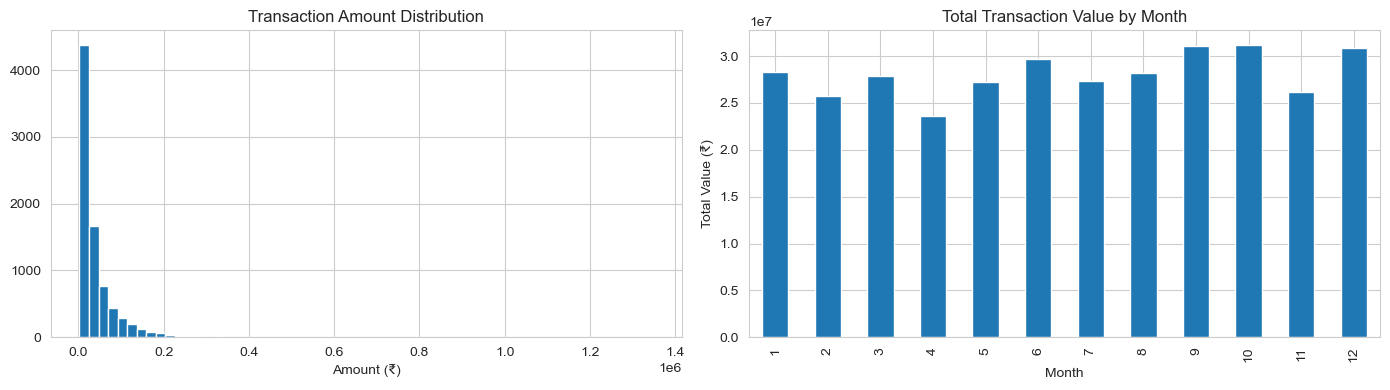

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['amount'].hist(bins=60, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (₹)')

df.groupby('month')['amount'].sum().plot(kind='bar', ax=axes[1])
axes[1].set_title('Total Transaction Value by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Value (₹)')

plt.tight_layout()
plt.show()

## 3. Rule-Based Audit Tests

Six rule-based audit tests, each returning the transaction IDs it flags
and why:

- **Duplicates** - same vendor + amount + date appearing more than once
- **Round numbers** - amounts that are exact multiples of 10,000
- **Off-hours / weekend postings** - entries outside normal business hours
- **Vendor concentration** - vendors representing >8% of total spend
- **Statistical outliers** - IQR-based outliers, computed per account
- **Month-end late-hour postings** - entries posted on/after day 28 of the
  month, at/after 18:00 (a fixed date/time rule, not a volume comparison)


In [7]:
from audit_tests import run_all_tests, benfords_law_check

rule_flags = run_all_tests(df)
print(f"Rule-based tests flagged {len(rule_flags)} unique transactions "
      f"out of {len(df)} total ({len(rule_flags)/len(df)*100:.1f}%)")
rule_flags.head(10)

Rule-based tests flagged 1143 unique transactions out of 8140 total (14.0%)


,transaction_id,n_tests_triggered,tests_triggered,reasons
0,JE104741,1,duplicate,Duplicate vendor+amount+date combination
1,JE100308,1,duplicate,Duplicate vendor+amount+date combination
2,JE103229,1,duplicate,Duplicate vendor+amount+date combination
3,JE104206,1,duplicate,Duplicate vendor+amount+date combination
4,JE108010,1,duplicate,Duplicate vendor+amount+date combination
5,JE105607,1,duplicate,Duplicate vendor+amount+date combination
6,JE103612,1,duplicate,Duplicate vendor+amount+date combination
7,JE108006,1,duplicate,Duplicate vendor+amount+date combination
8,JE103492,1,duplicate,Duplicate vendor+amount+date combination
9,JE108013,1,duplicate,Duplicate vendor+amount+date combination


Save the rule-based flags to disk (used by risk scoring and the report):

In [8]:
rule_flags.to_csv(os.path.join(DATA_DIR, 'rule_based_flags.csv'), index=False)
print(f"Saved to {DATA_DIR}/rule_based_flags.csv")

Saved to c:\Users\sonak\OneDrive\Desktop\sushi\pen drive\sonakshi_projects\Data_Analytics\AuditLens\auditlens\data/rule_based_flags.csv


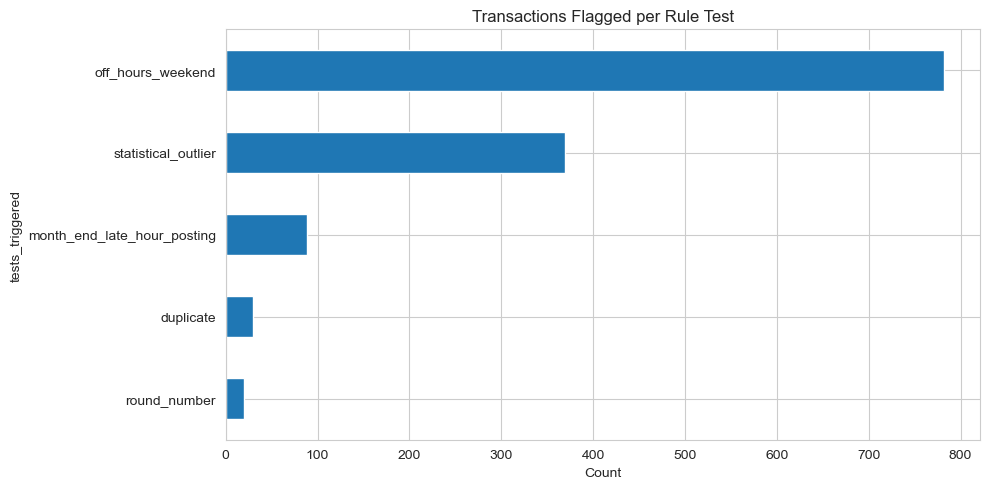

In [9]:
test_counts = (
    rule_flags['tests_triggered']
    .str.split(', ')
    .explode()
    .value_counts()
)
test_counts.plot(kind='barh')
plt.title('Transactions Flagged per Rule Test')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This shows how often each test fires. Section 7 shows what fraction of
the *planted* anomalies each test actually caught - the more relevant
measure of test quality.

In [10]:
print("Transactions flagged per rule test:")
print(test_counts.to_string())

Transactions flagged per rule test:
tests_triggered
off_hours_weekend              782
statistical_outlier            369
month_end_late_hour_posting     89
duplicate                       30
round_number                    20


## 4. Benford's Law Analysis

Naturally occurring financial amounts follow Benford's Law: lower leading
digits (1, 2) occur more often than higher ones (8, 9). Used here as a
population-level screening technique - a deviation from the expected
distribution can warrant further review, but does not by itself indicate
manual entry, rounding, or manipulation.

In [11]:
benford_df = benfords_law_check(df)
benford_df[['account', 'n_transactions', 'max_deviation', 'flag']].sort_values('max_deviation', ascending=False)

,account,n_transactions,max_deviation,flag
1,Accounts Receivable,829,0.226,REVIEW
8,Travel & Expense,804,0.221,REVIEW
9,Utilities,841,0.217,REVIEW
4,Marketing Spend,790,0.213,REVIEW
0,Accounts Payable,817,0.197,REVIEW
5,Office Supplies,775,0.179,REVIEW
6,Payroll,856,0.177,REVIEW
7,Rent,799,0.163,REVIEW
3,Inventory,812,0.161,REVIEW
2,Consulting Fees,817,0.110,REVIEW


**Result:** every account exceeds the 0.08 deviation threshold (all
flagged `REVIEW`), so the test isn't discriminating between accounts here.
On a real dataset, this would prompt revisiting the threshold, per-account
sample sizes, or whether Benford's Law fits these account types - not
treating every account as a finding.

Save the Benford's Law breakdown (used in the report's methodology section):

In [12]:
benford_df.to_csv(os.path.join(DATA_DIR, 'benford_analysis.csv'), index=False)
print(f"Saved to {DATA_DIR}/benford_analysis.csv")

Saved to c:\Users\sonak\OneDrive\Desktop\sushi\pen drive\sonakshi_projects\Data_Analytics\AuditLens\auditlens\data/benford_analysis.csv


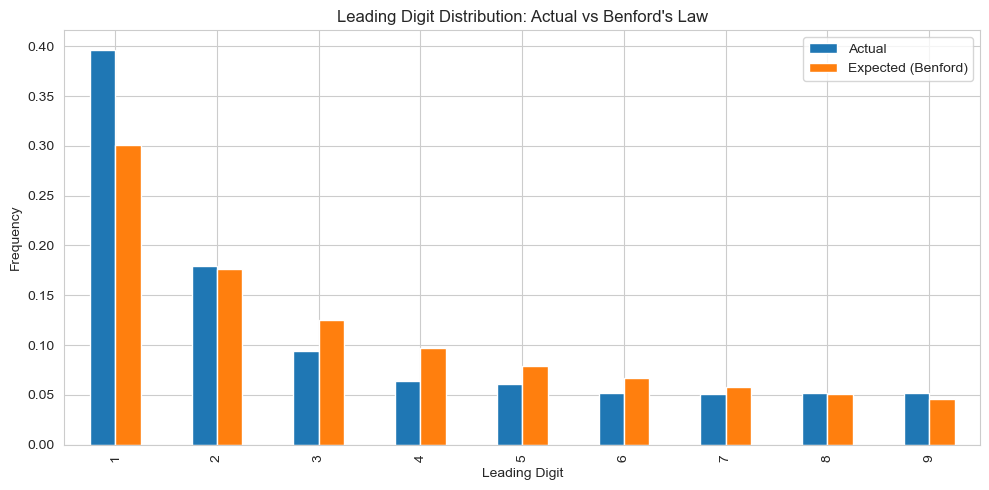

In [13]:
# Visualize actual vs expected leading-digit distribution, overall
from collections import Counter

def leading_digit(x):
    s = str(abs(x)).lstrip('0').replace('.', '')
    return int(s[0]) if s else None

digits = df['amount'].apply(leading_digit)
actual_dist = digits.value_counts(normalize=True).sort_index()
expected_dist = pd.Series({d: np.log10(1 + 1/d) for d in range(1, 10)})

comparison = pd.DataFrame({'Actual': actual_dist, 'Expected (Benford)': expected_dist})
comparison.plot(kind='bar')
plt.title("Leading Digit Distribution: Actual vs Benford's Law")
plt.xlabel('Leading Digit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 5. ML Anomaly Detection - Isolation Forest

The rule-based tests only catch what they're explicitly written to catch.
An Isolation Forest is trained on engineered features (amount, timing,
vendor frequency, vendor spend share, deviation from account median) to
catch anomalies that don't match a predefined rule.

In [14]:
from anomaly_detection import run_isolation_forest, engineer_features

ml_scores = run_isolation_forest(df)
n_flagged = (ml_scores['ml_flag'] == 'anomaly').sum()
print(f"Isolation Forest flagged {n_flagged} / {len(ml_scores)} transactions "
      f"({n_flagged/len(ml_scores)*100:.1f}%)")
ml_scores.sort_values('ml_anomaly_score', ascending=False).head(10)

Isolation Forest flagged 407 / 8140 transactions (5.0%)


,transaction_id,ml_anomaly_score,ml_flag
2267,JE108117,1.0000,anomaly
189,JE108130,0.9646,anomaly
2368,JE108106,0.9311,anomaly
7324,JE108102,0.9241,anomaly
3297,JE108127,0.8959,anomaly
2691,JE108054,0.8478,anomaly
313,JE108068,0.8428,anomaly
5098,JE108055,0.8410,anomaly
7048,JE108112,0.8327,anomaly
3919,JE108115,0.8320,anomaly


Save the ML anomaly scores:

In [15]:
ml_scores.to_csv(os.path.join(DATA_DIR, 'ml_anomaly_scores.csv'), index=False)
print(f"Saved to {DATA_DIR}/ml_anomaly_scores.csv")

Saved to c:\Users\sonak\OneDrive\Desktop\sushi\pen drive\sonakshi_projects\Data_Analytics\AuditLens\auditlens\data/ml_anomaly_scores.csv


**Note:** `ml_anomaly_score` is a normalized score, not a standard
Isolation Forest output - `anomaly_detection.py` inverts and min-max
scales the model's raw `decision_function` into a 0–1 range, where higher
values mean more anomalous relative to the rest of *this* dataset. It is
not a probability of fraud, and is not comparable across different runs.

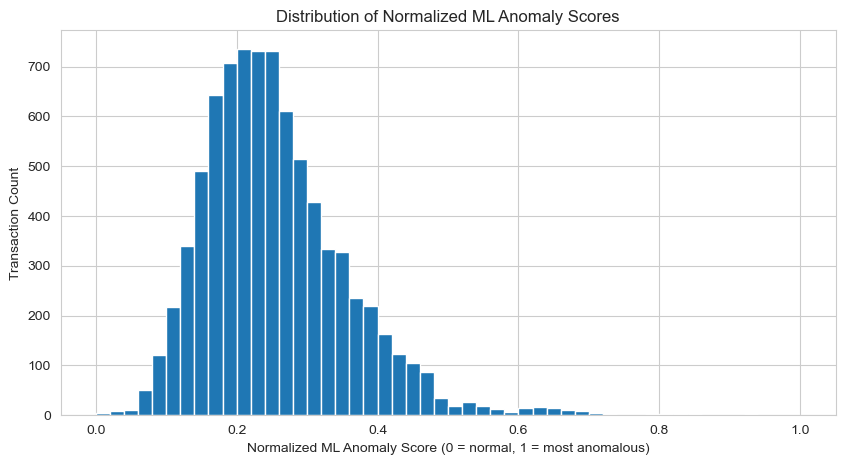

In [16]:
ml_scores['ml_anomaly_score'].hist(bins=50)
plt.title('Distribution of Normalized ML Anomaly Scores')
plt.xlabel('Normalized ML Anomaly Score (0 = normal, 1 = most anomalous)')
plt.ylabel('Transaction Count')
plt.show()

## 6. Combined Risk Scoring

Rule-based flags and the ML anomaly score are combined into one
`risk_score`. The rule component uses the **maximum severity** among
triggered tests, not a count - a single strong signal (e.g. an exact
duplicate) shouldn't need a second, weaker signal to register as high risk.

```
risk_score = 0.5 × max(rule test severity) + 0.5 × ML anomaly score
risk_level: High (>0.7)  |  Medium (0.4–0.7)  |  Low (<0.4)
```

In [17]:
from risk_scoring import combine_scores, validate_against_ground_truth

risk_df = combine_scores(df, rule_flags, ml_scores)
risk_df['risk_level'].value_counts()

risk_level
Low       7529
Medium     561
High        50
Name: count, dtype: int64

Save the final consolidated risk scores:

In [18]:
risk_df.to_csv(os.path.join(DATA_DIR, 'final_risk_scores.csv'), index=False)
print(f"Saved to {DATA_DIR}/final_risk_scores.csv")

Saved to c:\Users\sonak\OneDrive\Desktop\sushi\pen drive\sonakshi_projects\Data_Analytics\AuditLens\auditlens\data/final_risk_scores.csv


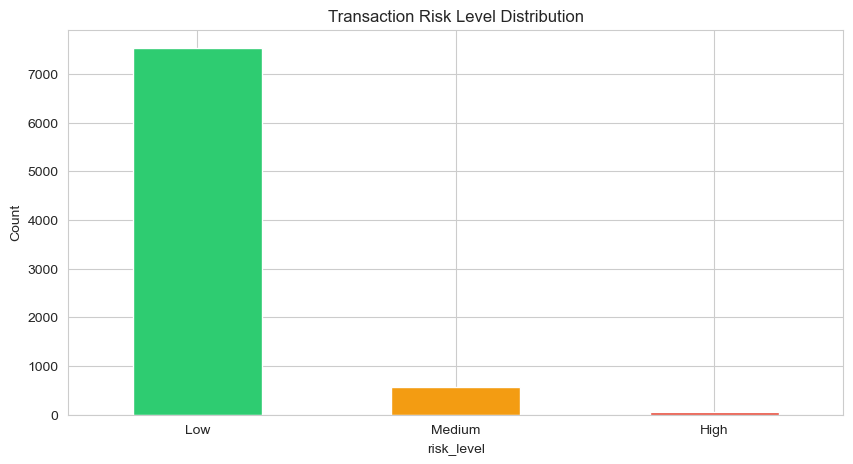

In [19]:
risk_df['risk_level'].value_counts().reindex(['Low', 'Medium', 'High']).plot(
    kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c']
)
plt.title('Transaction Risk Level Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [20]:
risk_df.sort_values('risk_score', ascending=False).head(10)[
    ['transaction_id', 'n_tests_triggered', 'tests_triggered', 'ml_anomaly_score', 'risk_score', 'risk_level']
]

,transaction_id,n_tests_triggered,tests_triggered,ml_anomaly_score,risk_score,risk_level
2267,JE108117,3.0,"off_hours_weekend, statistical_outlier, month_...",1.0000,0.9000,High
189,JE108130,3.0,"off_hours_weekend, statistical_outlier, month_...",0.9646,0.8823,High
2368,JE108106,3.0,"off_hours_weekend, statistical_outlier, month_...",0.9311,0.8656,High
7324,JE108102,3.0,"off_hours_weekend, statistical_outlier, month_...",0.9241,0.8620,High
3297,JE108127,3.0,"off_hours_weekend, statistical_outlier, month_...",0.8959,0.8480,High
2691,JE108054,1.0,statistical_outlier,0.8478,0.8239,High
313,JE108068,1.0,statistical_outlier,0.8428,0.8214,High
5098,JE108055,1.0,statistical_outlier,0.8410,0.8205,High
7048,JE108112,3.0,"off_hours_weekend, statistical_outlier, month_...",0.8327,0.8164,High
3919,JE108115,3.0,"off_hours_weekend, statistical_outlier, month_...",0.8320,0.8160,High


## 7. Validation Against Ground Truth

Because the dataset was synthetically generated, the true anomaly labels
are known. This measures recall (% of planted anomalies caught) and
precision (% of flags that were real) - a step that isn't possible on
unlabeled real audit data.

In [21]:
results = validate_against_ground_truth(risk_df)


--- VALIDATION AGAINST PLANTED GROUND TRUTH ---
Planted anomalies:            140
Flagged as High/Medium risk:  611
True positives caught:        107
Recall (of planted anomalies caught):    76.4%
Precision (of flags that were real):     17.5%

Recall by anomaly type:
anomaly_type
duplicate               100.0
month_end_spike         100.0
off_hours_weekend        72.2
round_number             95.0
statistical_outlier     100.0
vendor_concentration     22.9
Name: risk_level, dtype: float64


### Interpretation

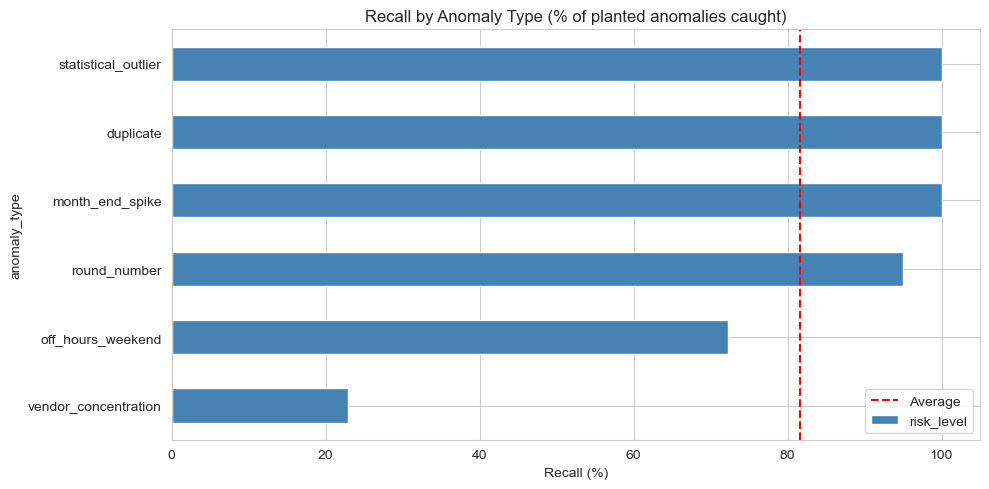

In [22]:
gt = pd.read_csv(os.path.join(DATA_DIR, 'ground_truth.csv'))
merged = risk_df.merge(gt, on='transaction_id', how='left')
merged['is_anomaly'] = merged['is_anomaly'].fillna(0).astype(int)

actual_anomalies = merged[merged['is_anomaly'] == 1]
recall_by_type = (
    actual_anomalies.groupby('anomaly_type')['risk_level']
    .apply(lambda s: s.isin(['High', 'Medium']).mean() * 100)
    .sort_values()
)

recall_by_type.plot(kind='barh', color='steelblue')
plt.title('Recall by Anomaly Type (% of planted anomalies caught)')
plt.xlabel('Recall (%)')
plt.axvline(x=recall_by_type.mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Key Findings Summary

In [24]:
full = risk_df.merge(df, on='transaction_id', how='left')

print("=== EXECUTIVE SUMMARY ===")
print(f"Total transactions analyzed: {len(full):,}")
print(f"Total transaction value:     ₹{full['amount'].sum():,.2f}")
print(f"High risk transactions:      {(full['risk_level']=='High').sum():,} "
      f"({(full['risk_level']=='High').mean()*100:.1f}%)")
print(f"Medium risk transactions:    {(full['risk_level']=='Medium').sum():,} "
      f"({(full['risk_level']=='Medium').mean()*100:.1f}%)")

print("\nTop 5 vendors by flagged transaction value:")
top_vendors = (
    full[full['risk_level'].isin(['High', 'Medium'])]
    .groupby('vendor')['amount'].sum()
    .sort_values(ascending=False)
    .head(5)
)
print(top_vendors)

=== EXECUTIVE SUMMARY ===
Total transactions analyzed: 8,140
Total transaction value:     ₹337,178,531.87
High risk transactions:      50 (0.6%)
Medium risk transactions:    561 (6.9%)

Top 5 vendors by flagged transaction value:
vendor
Morales-Jones                    3.466979e+06
Snyder, Campos and Callahan      2.841916e+06
Mcclain, Miller and Henderson    2.713853e+06
Doyle Ltd                        2.335565e+06
Dudley Group                     2.229023e+06
Name: amount, dtype: float64


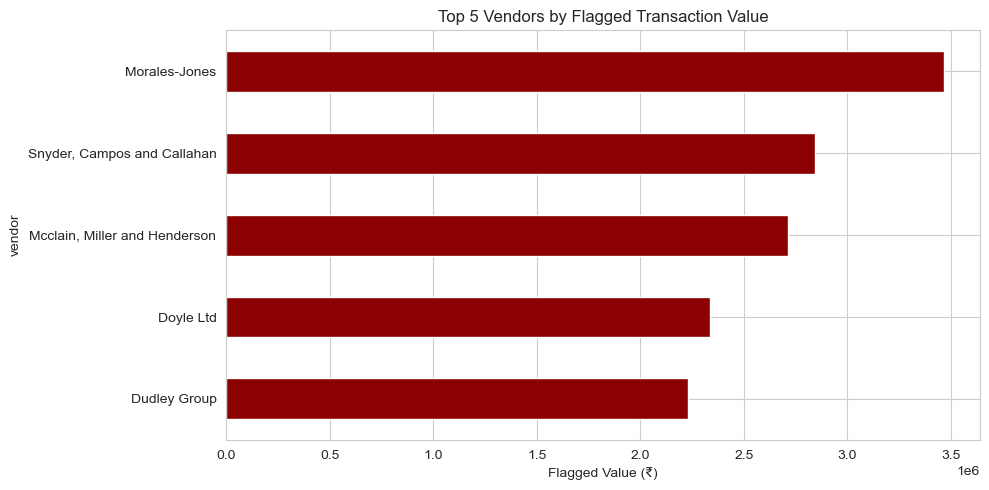

In [25]:
top_vendors.plot(kind='barh', color='darkred')
plt.title('Top 5 Vendors by Flagged Transaction Value')
plt.xlabel('Flagged Value (₹)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Audit Findings Report & Dashboard Export

In [26]:
from generate_report import generate_report

report_path = generate_report()

# Dashboard-ready export: one flat table with everything Power BI/Streamlit needs
dashboard_export = risk_df.merge(df, on='transaction_id', how='left')
dashboard_path = os.path.join(DATA_DIR, 'dashboard_export.csv')
dashboard_export.to_csv(dashboard_path, index=False)

print('Pipeline complete. All output files regenerated:')
print(f'  Report:            reports/audit_findings_report.md')
print(f'  Dashboard export:  data/dashboard_export.csv')
print(f'  Risk scores:       data/final_risk_scores.csv')
print(f'  SQLite DB:         data/auditlens.db')

Report saved to c:\Users\sonak\OneDrive\Desktop\sushi\pen drive\sonakshi_projects\Data_Analytics\AuditLens\auditlens\reports\audit_findings_report.md
Pipeline complete. All output files regenerated:
  Report:            reports/audit_findings_report.md
  Dashboard export:  data/dashboard_export.csv
  Risk scores:       data/final_risk_scores.csv
  SQLite DB:         data/auditlens.db
